Load CSV Dataset & Clean Data

In [13]:
import pandas as pd
import numpy as np
# Load CSV file
df = pd.read_csv("online_retail_II.csv")
# Check columns
df.head()
df.columns

Index(['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'Price', 'Customer ID', 'Country'],
      dtype='object')

Clean Null Customers & Canceled Orders

In [14]:
# Remove rows with missing CustomerID
df = df.dropna(subset=["Customer ID"])
# Remove canceled invoices (start with C)
df = df[~df["Invoice"].astype(str).str.startswith("C")]
# Remove negative quantity
df = df[df["Quantity"] > 0]
df.shape

(805620, 8)

Convert InvoiceDate to Datetime

In [19]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

Compute RFM

Create TotalPrice, Snapshot Date, RFM Table

In [20]:
df["TotalPrice"] = df["Quantity"] * df["Price"]

In [21]:
snapshot_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)

In [22]:
rfm = df.groupby("Customer ID").agg({
    "InvoiceDate": lambda x: (snapshot_date - x.max()).days,
    "Invoice": "nunique",
    "TotalPrice": "sum"
})

rfm.columns = ["Recency", "Frequency", "Monetary"]
rfm.head()

,Recency,Frequency,Monetary
Customer ID,,,
12346.0,326,12,77556.46
12347.0,2,8,5633.32
12348.0,75,5,2019.40
12349.0,19,4,4428.69
12350.0,310,1,334.40


Create RFM Scores

In [7]:
rfm["R_score"] = pd.qcut(rfm["Recency"], 4, labels=[4,3,2,1])
rfm["F_score"] = pd.qcut(rfm["Frequency"].rank(method="first"), 4, labels=[1,2,3,4])
rfm["M_score"] = pd.qcut(rfm["Monetary"], 4, labels=[1,2,3,4])

rfm["RFM_Score"] = rfm["R_score"].astype(str) + rfm["F_score"].astype(str)

Assign Segment Labels

In [8]:
def segment_customer(row):
    if row["R_score"] == 4 and row["F_score"] == 4:
        return "Champions"
    elif row["F_score"] >= 3:
        return "Loyal Customers"
    elif row["R_score"] >= 3:
        return "Potential Loyalists"
    elif row["R_score"] == 2:
        return "At Risk"
    else:
        return "Hibernating"

rfm["Segment"] = rfm.apply(segment_customer, axis=1)

Bar Chart Visualization

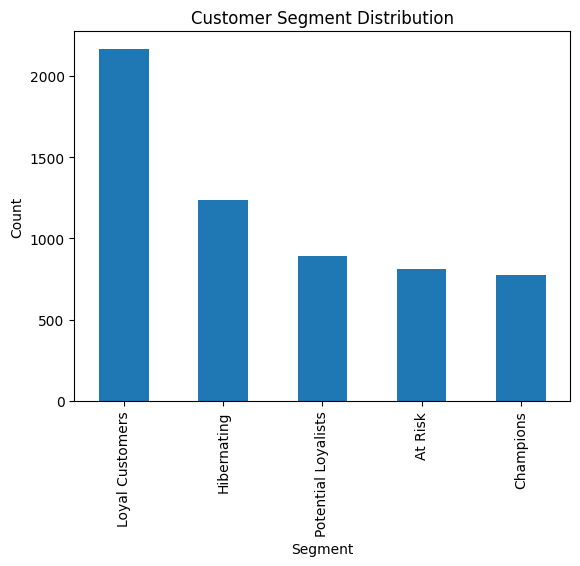

In [9]:
import matplotlib.pyplot as plt

plt.figure()
rfm["Segment"].value_counts().plot(kind="bar")

plt.title("Customer Segment Distribution")
plt.xlabel("Segment")
plt.ylabel("Count")

plt.show()

Export CSV

In [10]:
rfm.to_csv("customer_rfm_segmentation.csv")

Sort Customers by Best RFM Score

In [11]:
rfm = rfm.sort_values(["R_score","F_score","M_score"], ascending=False)

Check Segment Distribution %

In [12]:
rfm["Segment"].value_counts(normalize=True) * 100

,proportion
Segment,
Loyal Customers,36.830471
Hibernating,20.999830
Potential Loyalists,15.218500
At Risk,13.790172
Champions,13.161027
